# GRU Sequential Sensor Forecaster

Gated Recurrent Units (GRUs) simplify LSTM networks by combining cell states and hidden states into a single channels channel, controlled by update and reset gates. This reduces network parameters while maintaining sequence memory. This notebook generates synthetic daily sensor load coordinates (600 sequences, 15 steps), trains a GRU forecaster in PyTorch, and plots test predictions alignment in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate synthetic sensor sequences (600 sequences, 15 input steps -> 1 target prediction)
np.random.seed(250)
n_seqs = 600
seq_len = 15

t = np.linspace(0, 100, n_seqs + seq_len)
# Base sine signal with trend
sensor_signal = np.sin(t * 0.1) * 10.0 + t * 0.05 + np.random.normal(0, 0.4, len(t))

X_data, y_data = [], []
for i in range(n_seqs):
    X_data.append(sensor_signal[i:i+seq_len])
    y_data.append(sensor_signal[i+seq_len])

X = np.array(X_data) # [600, 15]
y = np.array(y_data) # [600]

# Add feature channel: shape [600, 15, 1]
X = np.expand_dims(X, axis=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print("Train Inputs shape:  ", X_train_t.shape)
print("Train Targets shape: ", y_train_t.shape)



Train Inputs shape:   torch.Size([480, 15, 1])
Train Targets shape:  torch.Size([480])


## GRU Forecaster Model Architecture

We implement the GRU model in PyTorch:
1. **GRU Layer**: Process sequence steps using hidden dimension size=32.
2. **Linear Predictor**: Takes the final step hidden vector to predict the next value.



In [2]:
class SensorGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32):
        super(SensorGRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # rnn_out shape: [batch, seq_len, hidden_dim]
        # h_n shape: [1, batch, hidden_dim]
        rnn_out, h_n = self.gru(x)
        # Select output of final sequence step
        final_out = rnn_out[:, -1, :]
        preds = self.fc(final_out).squeeze(1)
        return preds

model = SensorGRU()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## GRU Optimization Training

We train the forecaster for 110 epochs, computing predictions and evaluation losses.



In [3]:
epochs = 110
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | Training MSE Loss: {loss.item():.4f}")

# Calculate test loss
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t).item()
    
print(f"\nFinal Test MSE Loss: {test_loss:.4f}")



Epoch  20/110 | Training MSE Loss: 12.7698
Epoch  40/110 | Training MSE Loss: 2.0941
Epoch  60/110 | Training MSE Loss: 0.6158
Epoch  80/110 | Training MSE Loss: 0.3491
Epoch 100/110 | Training MSE Loss: 0.2753

Final Test MSE Loss: 0.2261


## Actual vs. Forecasted Telemetry Plots

Using Matplotlib, we trace actual ground truths vs. GRU predictions for the first 50 test samples to verify temporal tracking.



<cell>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



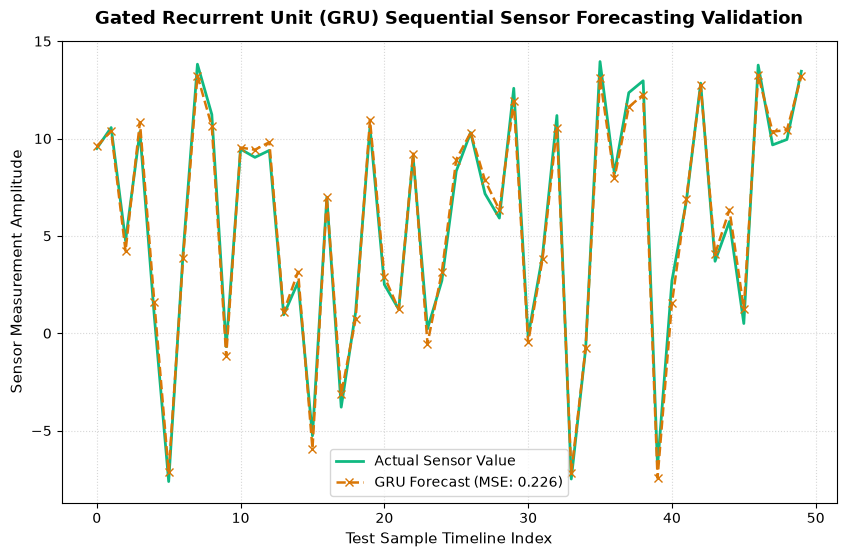

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(y_test[:50], color='#10B981', label='Actual Sensor Value', linewidth=2.0)
plt.plot(test_preds[:50].numpy(), color='#D97706', linestyle='--', marker='x', label=f'GRU Forecast (MSE: {test_loss:.3f})', linewidth=1.8)

plt.title('Gated Recurrent Unit (GRU) Sequential Sensor Forecasting Validation', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Test Sample Timeline Index', fontsize=11)
plt.ylabel('Sensor Measurement Amplitude', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
